### Import libraries and load dataset

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("transactions_dirty.csv")
df

,transaction_id,customer_id,account_id,transaction_date,transaction_type,amount
0,TX1000000,CUST2309,ACC141831,2024-08-26,Withdrawal,6799.74
1,TX1000001,CUST1228,ACC157817,2024-08-19,Deposit,7135.49
2,TX1000002,CUST1051,ACC187965,2024-03-18,Withdrawal,11684.38
3,TX1000003,CUST2518,ACC115420,2024-11-29,Withdrawal,4374.30
4,TX1000004,CUST1563,ACC135737,2024-06-18,Bank Transfer,18830.95
...,...,...,...,...,...,...
10145,TX1000458,CUST1245,ACC176569,2024-09-24,Bank Transfer,14229.67
10146,TX1003182,CUST1294,ACC109166,2024-05-07,Bank Transfer,3755.65
10147,TX1001664,CUST2264,ACC165260,2024-06-04,Bank Transfer,9528.49
10148,TX1008185,CUST2176,ACC138288,2024-01-15,Deposit,2297.72


### Check for nulls

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10150 entries, 0 to 10149
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    10150 non-null  object 
 1   customer_id       10150 non-null  object 
 2   account_id        10150 non-null  object 
 3   transaction_date  10100 non-null  object 
 4   transaction_type  9948 non-null   object 
 5   amount            10048 non-null  float64
dtypes: float64(1), object(5)
memory usage: 475.9+ KB


### Change data type of transaction_date to datetime from object

In [3]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10150 entries, 0 to 10149
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10150 non-null  object        
 1   customer_id       10150 non-null  object        
 2   account_id        10150 non-null  object        
 3   transaction_date  10100 non-null  datetime64[ns]
 4   transaction_type  9948 non-null   object        
 5   amount            10048 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 475.9+ KB


### Deal with Negative Values in Amount Column

In [4]:
df.describe()

,amount
count,10048.000000
mean,10033.870373
std,6898.607319
min,-37679.150000
25%,4976.017500
50%,9913.195000
75%,15002.910000
max,94179.300000


In [5]:
negative_amount = df[df['amount']<0]
len(negative_amount)

98

In [6]:
# handling negative amount
df = df[df['amount']>=0]
negative_amount = df[df['amount']<0]
negative_amount

,transaction_id,customer_id,account_id,transaction_date,transaction_type,amount


### Fill Null Values in Amount Column with mean

In [7]:
df['amount'] = df['amount'].fillna(df['amount'].mean())
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9950 entries, 0 to 10149
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9950 non-null   object        
 1   customer_id       9950 non-null   object        
 2   account_id        9950 non-null   object        
 3   transaction_date  9901 non-null   datetime64[ns]
 4   transaction_type  9750 non-null   object        
 5   amount            9950 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 544.1+ KB


### Drop Null Values

In [8]:
df = df.dropna(axis=0, subset=(['transaction_date', 'transaction_type', 'transaction_date']))
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9701 entries, 0 to 10149
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9701 non-null   object        
 1   customer_id       9701 non-null   object        
 2   account_id        9701 non-null   object        
 3   transaction_date  9701 non-null   datetime64[ns]
 4   transaction_type  9701 non-null   object        
 5   amount            9701 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 530.5+ KB


### Check duplicate rows

In [9]:
duplicate_rows = df[df.duplicated()]
len(duplicate_rows)

144

In [10]:
# drop duplicates
df.drop_duplicates(inplace=True)

#check again
duplicate_rows = df[df.duplicated()]
len(duplicate_rows)

0

### Normalize the column transaction_type

In [12]:
df['transaction_type'] = df['transaction_type'].str.title()
df.head(30)

,transaction_id,customer_id,account_id,transaction_date,transaction_type,amount
0,TX1000000,CUST2309,ACC141831,2024-08-26,Withdrawal,6799.74
1,TX1000001,CUST1228,ACC157817,2024-08-19,Deposit,7135.49
2,TX1000002,CUST1051,ACC187965,2024-03-18,Withdrawal,11684.38
3,TX1000003,CUST2518,ACC115420,2024-11-29,Withdrawal,4374.30
4,TX1000004,CUST1563,ACC135737,2024-06-18,Bank Transfer,18830.95
5,TX1000005,CUST1501,ACC119571,2024-02-07,Deposit,15521.22
6,TX1000006,CUST1457,ACC120643,2024-04-03,Pos,4420.32
7,TX1000007,CUST1285,ACC135866,2024-11-27,Deposit,12724.21
8,TX1000008,CUST2508,ACC115002,2024-10-21,Banktransfer,16500.03
9,TX1000009,CUST1209,ACC101999,2024-06-22,Bank Transfer,3412.60


In [13]:
# Define the mapping
mapping = {
    'Pos Purchase': 'Pos',
    'Banktransfer': 'Bank Transfer',
    'Bank-Transfer': 'Bank Transfer'
}

# Apply the replacements
df['transaction_type'] = df['transaction_type'].replace(mapping)
df.head(20)

,transaction_id,customer_id,account_id,transaction_date,transaction_type,amount
0,TX1000000,CUST2309,ACC141831,2024-08-26,Withdrawal,6799.74
1,TX1000001,CUST1228,ACC157817,2024-08-19,Deposit,7135.49
2,TX1000002,CUST1051,ACC187965,2024-03-18,Withdrawal,11684.38
3,TX1000003,CUST2518,ACC115420,2024-11-29,Withdrawal,4374.30
4,TX1000004,CUST1563,ACC135737,2024-06-18,Bank Transfer,18830.95
5,TX1000005,CUST1501,ACC119571,2024-02-07,Deposit,15521.22
6,TX1000006,CUST1457,ACC120643,2024-04-03,Pos,4420.32
7,TX1000007,CUST1285,ACC135866,2024-11-27,Deposit,12724.21
8,TX1000008,CUST2508,ACC115002,2024-10-21,Bank Transfer,16500.03
9,TX1000009,CUST1209,ACC101999,2024-06-22,Bank Transfer,3412.60


### 1. Monthly Deposits vs Withdrawals (Cash Flow Trend)

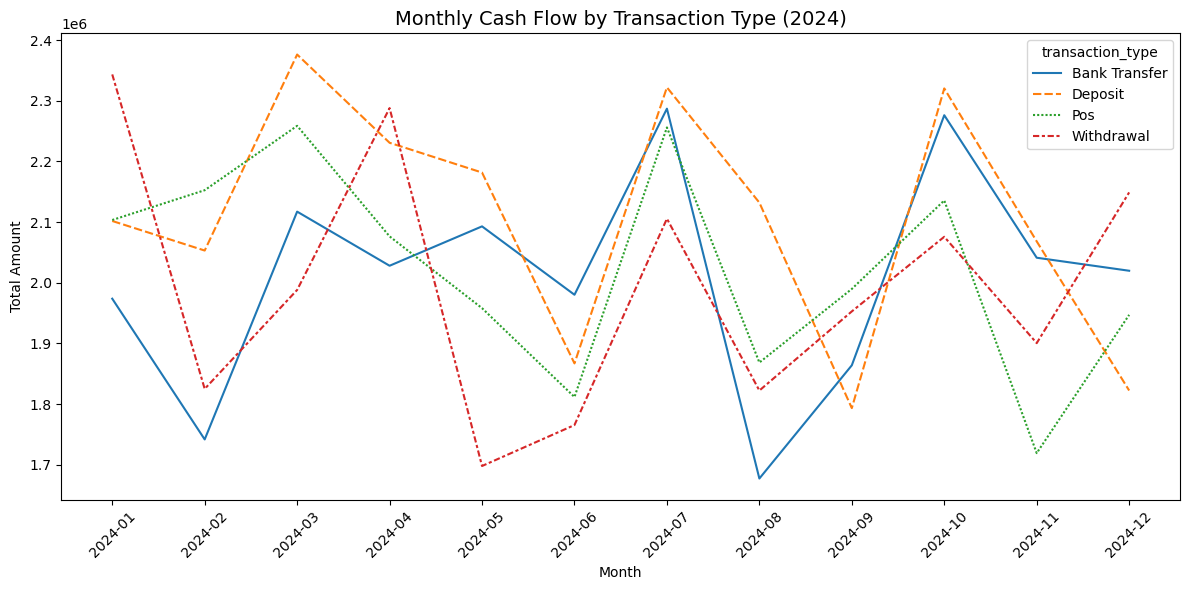

In [14]:
df['month'] = df['transaction_date'].dt.to_period('M').astype(str)

monthly = df.groupby(['month', 'transaction_type'])['amount'].sum().reset_index()
monthly_pivot = monthly.pivot(index='month', columns='transaction_type', values='amount')

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_pivot)
plt.title("Monthly Cash Flow by Transaction Type (2024)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Transaction Type Breakdown (POS, Transfer, Deposit, Withdrawal)

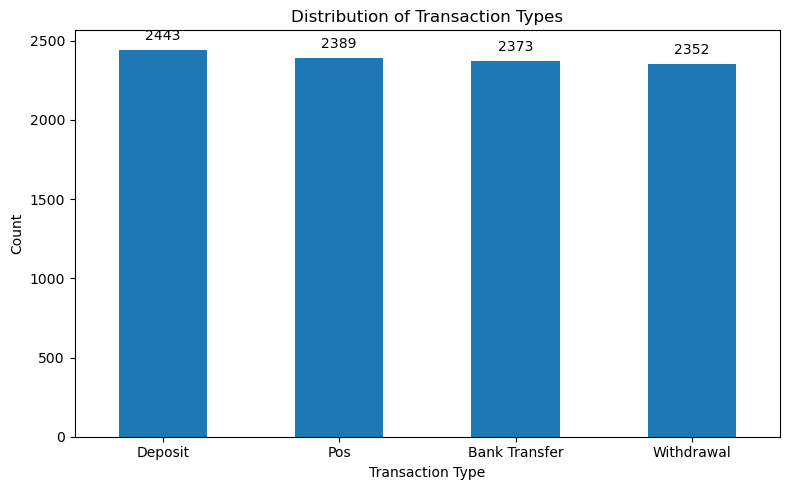

In [39]:
plt.figure(figsize=(8,5))
ax = df['transaction_type'].value_counts().plot(kind='bar')
plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=360)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout() # Ensures labels fit
plt.show()

### 3. Outlier Detection in Amounts (Boxplot)

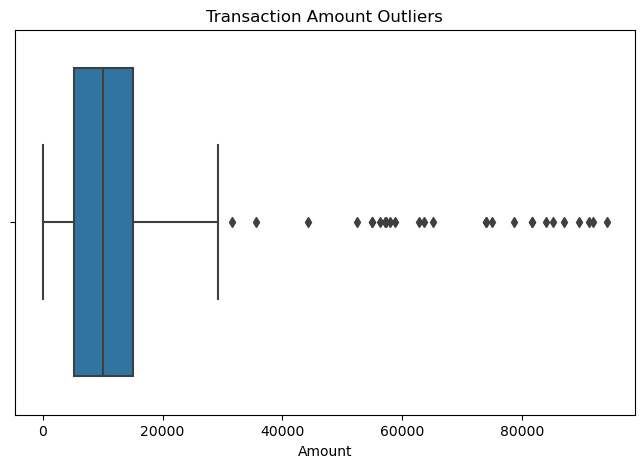

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['amount'])
plt.title("Transaction Amount Outliers")
plt.xlabel("Amount")
plt.show()

### 4. Top 10 Customers by Total Transaction Amount

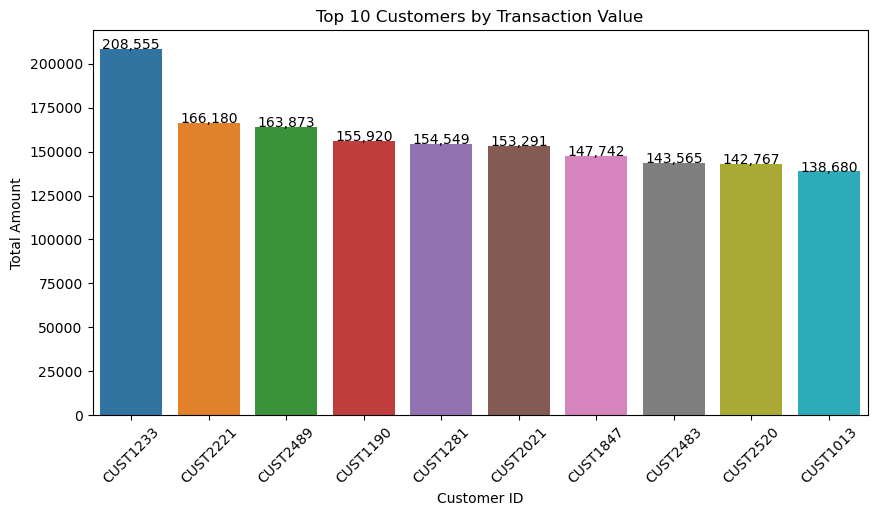

In [32]:
plt.figure(figsize=(10,5))
# Store the BarContainer object returned by sns.barplot
ax = sns.barplot(x=top_customers.index, y=top_customers.values)

plt.title("Top 10 Customers by Transaction Value")
plt.xlabel("Customer ID")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)

# --- Code to add values on the bars ---
for index, value in enumerate(top_customers.values):
    # ax.text(x, y + offset, text, color='black', ha='center')
    # x is the index of the bar, y is the value, offset moves the text slightly above the bar
    ax.text(index, value + 5, f'{value:,.0f}', color='black', ha="center")

plt.show()

### 5. Transaction Volume by Transaction Type

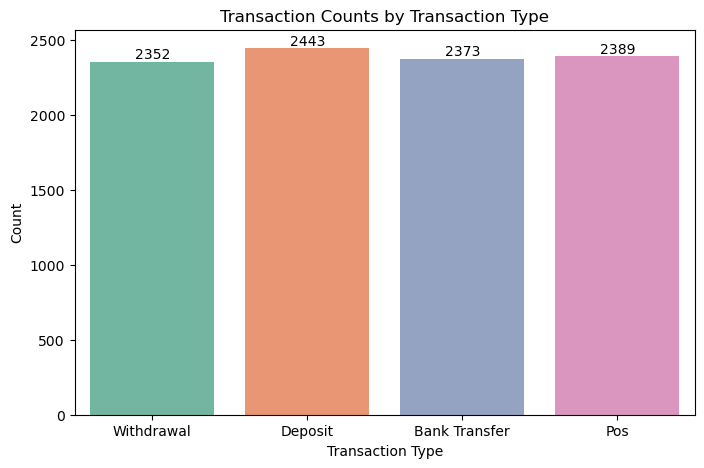

In [40]:
plt.figure(figsize=(8, 5))
# 1. Assign the plot to a variable 'ax'
ax = sns.countplot(data=df, x='transaction_type', palette='Set2') 

# 2. Add labels to the bars
for container in ax.containers:
    ax.bar_label(container)

plt.title('Transaction Counts by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

### 6. Digital vs Non-Digital Channel Usage

In [24]:
df['transaction_type'].unique()

array(['Withdrawal', 'Deposit', 'Bank Transfer', 'Pos'], dtype=object)

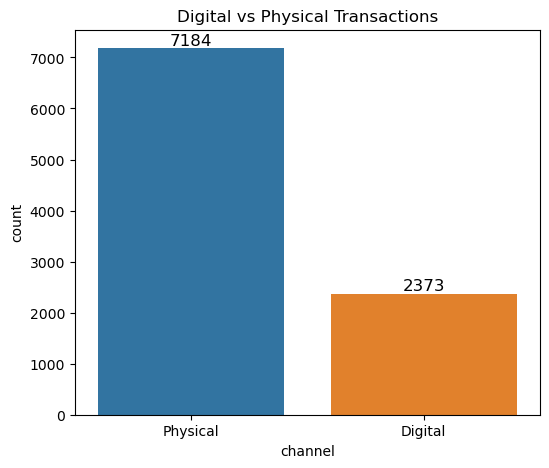

In [34]:
## (assuming POS + transfers = digital)
df['channel'] = df['transaction_type'].apply(
    lambda x: 'Digital' if x in ['POS', 'Bank Transfer'] else 'Physical'
)

# Plotting with value labels
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='channel') # Assign the plot to a variable 'ax'

# Add value labels to the bars
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2.,  # X-coordinate for the label (center of the bar)
        p.get_height(),                  # Y-coordinate for the label (top of the bar)
        '{:.0f}'.format(p.get_height()), # The text to display (the count value)
        fontsize=12,                     # Optional: adjust font size
        color='black',                   # Optional: adjust font color
        ha='center',                     # Horizontal alignment: center
        va='bottom'                      # Vertical alignment: bottom
    )

plt.title("Digital vs Physical Transactions")
plt.show()